In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('../data/irosva.mx.training.clean.csv')
df_test = pd.read_csv('../data/irosva.mx - irosva.mx.test.csv')
df_truth = pd.read_csv('../data/irosva.mx.test.truth.csv')

X_train = df_train['MESSAGE_CLEAN']
y_train = df_train['IS_IRONIC']

X_test = df_test['MESSAGE']
y_test = df_truth['IS_IRONIC']

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (2400,)
Test: (600,)


In [3]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Matriz TF-IDF train: {X_train_tfidf.shape}")

Matriz TF-IDF train: (2400, 5000)


In [4]:
# class_weight balanced para manejar el desbalance 2:1
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
print("Modelo entrenado")

Modelo entrenado


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr, X_train_tfidf, y_train, cv=cv, scoring='f1_macro')
print(f"F1-Macro por fold: {scores.round(3)}")
print(f"F1-Macro promedio: {scores.mean():.3f} (+/- {scores.std():.3f})")

F1-Macro por fold: [0.662 0.635 0.643 0.621 0.646]
F1-Macro promedio: 0.641 (+/- 0.013)


In [6]:
y_pred = lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=['No irónico', 'Irónico']))
print(f"F1-Macro en test: {f1_score(y_test, y_pred, average='macro'):.3f}")

              precision    recall  f1-score   support

  No irónico       0.67      0.67      0.67       401
     Irónico       0.34      0.34      0.34       199

    accuracy                           0.56       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.56      0.56      0.56       600

F1-Macro en test: 0.508


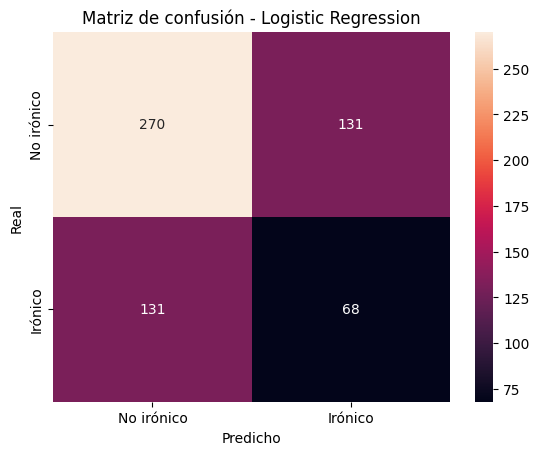

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['No irónico', 'Irónico'],
            yticklabels=['No irónico', 'Irónico'])
plt.title('Matriz de confusión - Logistic Regression')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()